In [ ]:
import yfinance as yf
import pandas as pd

# Fetching 30 years of historical data for AAPL
ticker = "AAPL"
data = yf.Ticker(ticker).history(period="30y")

print("First few rows of the data:")
print(data.head())

print("\nLast few rows of the data:")
print(data.tail())

print("\nSummary of the data:")
print(data.describe())

First few rows of the data:
                               Open      High       Low     Close     Volume  \
Date                                                                           
1993-12-02 00:00:00-05:00  0.234289  0.236134  0.228755  0.234289  100654400   
1993-12-03 00:00:00-05:00  0.234289  0.236134  0.228755  0.232445  120467200   
1993-12-06 00:00:00-05:00  0.232445  0.239824  0.230600  0.237979  156979200   
1993-12-07 00:00:00-05:00  0.236134  0.237979  0.232445  0.237979   63851200   
1993-12-08 00:00:00-05:00  0.236134  0.237978  0.232444  0.235211   39592000   

                           Dividends  Stock Splits  
Date                                                
1993-12-02 00:00:00-05:00        0.0           0.0  
1993-12-03 00:00:00-05:00        0.0           0.0  
1993-12-06 00:00:00-05:00        0.0           0.0  
1993-12-07 00:00:00-05:00        0.0           0.0  
1993-12-08 00:00:00-05:00        0.0           0.0  

Last few rows of the data:
            

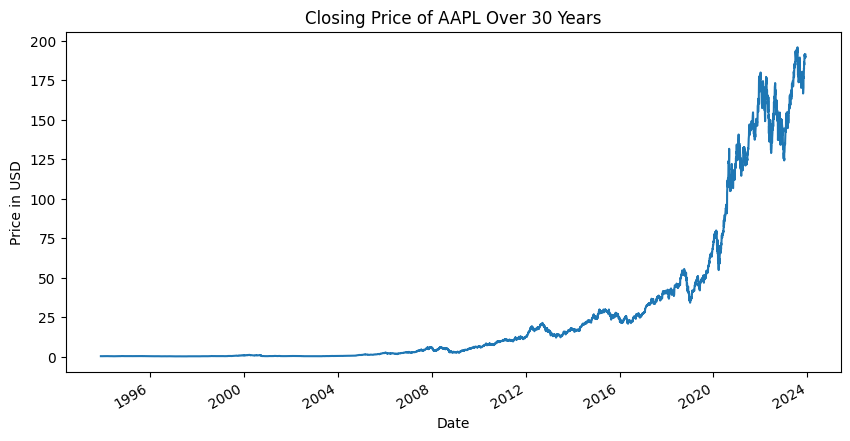

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
data['Close'].plot(title=f'Closing Price of {ticker} Over 30 Years')
plt.ylabel('Price in USD')
plt.show()

In [ ]:
import os
os.chdir("/usr")

In [ ]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz -P /usr
!tar -xzf ta-lib-0.4.0-src.tar.gz

--2023-12-02 23:44:50--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 204.68.111.105
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|204.68.111.105|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2023-12-02 23:44:50--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 204.68.111.105
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://nchc.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2023-12-02 23:44:51--  http://nchc.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving nchc.dl.sourceforge.n

In [ ]:
import os
os.chdir('/usr/ta-lib')

In [ ]:
!./configure --prefix=/usr
!make
!sudo make install

checking for a BSD-compatible install... /usr/bin/install -c
checking whether build environment is sane... yes
checking for a thread-safe mkdir -p... /usr/bin/mkdir -p
checking for gawk... no
checking for mawk... mawk
checking whether make sets $(MAKE)... yes
checking for gcc... gcc
checking for C compiler default output file name... a.out
checking whether the C compiler works... yes
checking whether we are cross compiling... no
checking for suffix of executables... 
checking for suffix of object files... o
checking whether we are using the GNU C compiler... yes
checking whether gcc accepts -g... yes
checking for gcc option to accept ISO C89... none needed
checking for style of include used by make... GNU
checking dependency style of gcc... gcc3
checking build system type... x86_64-unknown-linux-gnu
checking host system type... x86_64-unknown-linux-gnu
checking for a sed that does not truncate output... /usr/bin/sed
checking for grep that handles long lines and -e... /usr/bin/grep
chec

In [ ]:
!pip install TA-Lib

  Using cached TA-Lib-0.4.28.tar.gz (357 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for TA-Lib: filename=TA_Lib-0.4.28-cp310-cp310-linux_x86_64.whl size=2017535 sha256=10a87d135b2cc442f1cc136c977af597fa9b1ba0af6b42351c82853fca6e9281
  Stored in directory: /root/.cache/pip/wheels/66/54/9d/10bfd00931c0c993f373269d350635df520b5064e5290a9d94
Successfully built TA-Lib


In [ ]:
import talib as ta

# Calculate the Simple Moving Average (SMA) Crossover
sma_short_period = 50  # Short-term SMA
sma_long_period = 200  # Long-term SMA

data['SMA_short'] = ta.SMA(data['Close'], timeperiod=sma_short_period)
data['SMA_long'] = ta.SMA(data['Close'], timeperiod=sma_long_period)
data['Signal'] = 0  # Default no signal
data['Signal'][sma_long_period:] = (data['SMA_short'][sma_long_period:] > data['SMA_long'][sma_long_period:]).astype(int)
data['Signal'] = data['Signal'].shift()  # Shifting signal for next day's action

<ipython-input-12-799070b665da>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][sma_long_period:] = (data['SMA_short'][sma_long_period:] > data['SMA_long'][sma_long_period:]).astype(int)


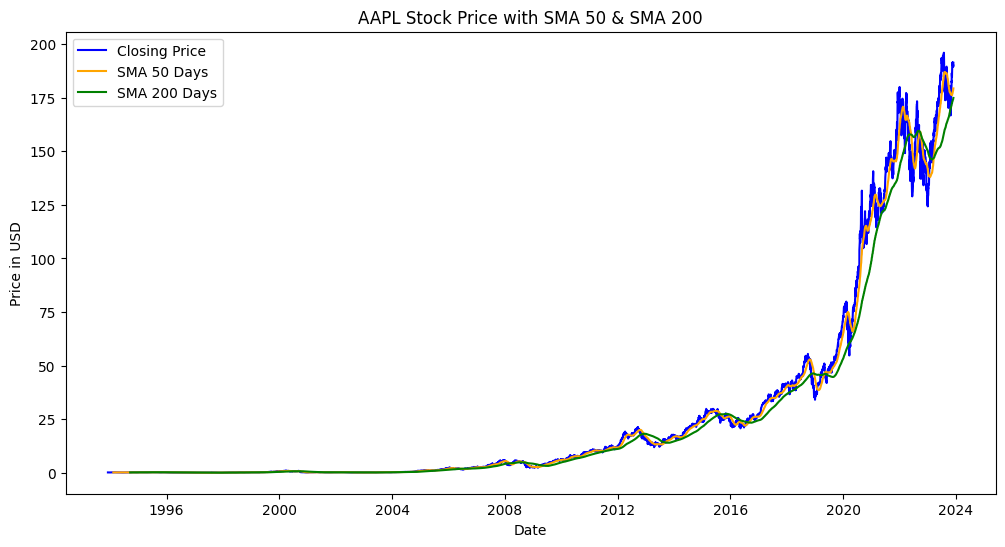

In [ ]:
# Plot the Closing Price, Short-term SMA, and Long-term SMA
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Closing Price', color='blue')
plt.plot(data.index, data['SMA_short'], label=f'SMA {sma_short_period} Days', color='orange')
plt.plot(data.index, data['SMA_long'], label=f'SMA {sma_long_period} Days', color='green')

# Adding title and labels
plt.title(f'{ticker} Stock Price with SMA {sma_short_period} & SMA {sma_long_period}')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

# Show the plot
plt.show()

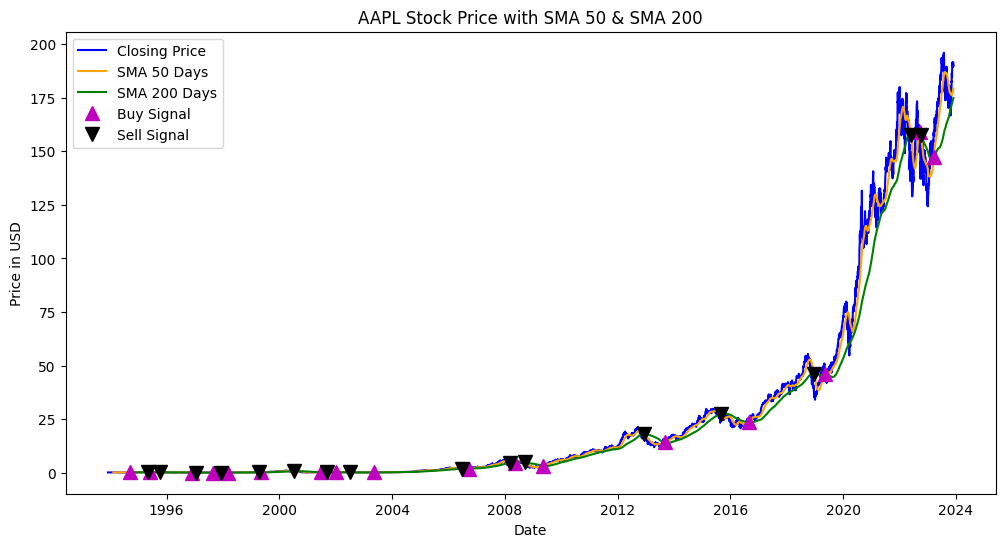

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Identifying the crossover points
crossovers = pd.DataFrame(index=data.index)
crossovers['price'] = data['Close']
crossovers['short_sma'] = data['SMA_short']
crossovers['long_sma'] = data['SMA_long']
crossovers['signal'] = 0.0
crossovers['signal'][sma_short_period:] = np.where(crossovers['short_sma'][sma_short_period:] > crossovers['long_sma'][sma_short_period:], 1.0, 0.0)
crossovers['positions'] = crossovers['signal'].diff()

# Plotting the closing price, short-term SMA, and long-term SMA
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Closing Price', color='blue')
plt.plot(data.index, data['SMA_short'], label=f'SMA {sma_short_period} Days', color='orange')
plt.plot(data.index, data['SMA_long'], label=f'SMA {sma_long_period} Days', color='green')

# Plotting the crossovers
plt.plot(crossovers.loc[crossovers.positions == 1].index, crossovers.short_sma[crossovers.positions == 1], '^', markersize=10, color='m', label='Buy Signal')
plt.plot(crossovers.loc[crossovers.positions == -1].index, crossovers.short_sma[crossovers.positions == -1], 'v', markersize=10, color='k', label='Sell Signal')

# Adding title and labels
plt.title(f'{ticker} Stock Price with SMA {sma_short_period} & SMA {sma_long_period}')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()

# Show the plot
plt.show()

In [ ]:
# Buy and Hold Strategy
investment_amount = 1000 #Monthly Investment Amount
data['MonthStart'] = data.index.to_series().dt.is_month_start
data['BuyHoldInvestment'] = data['MonthStart'].astype(int) * investment_amount
data['BuyHoldCumInvestment'] = data['BuyHoldInvestment'].cumsum()
data['BuyHoldShares'] = data['BuyHoldInvestment'] / data['Close']
data['BuyHoldTotalShares'] = data['BuyHoldShares'].cumsum()
data['BuyHoldValue'] = data['BuyHoldTotalShares'] * data['Close']

In [ ]:
buy_hold_final_value = data['BuyHoldValue'].iloc[-1]
years = 30
buy_hold_annual_return = ((buy_hold_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / years)) - 1
print(f"Buy and Hold Strategy - Final Value: ${buy_hold_final_value:.2f}")
print(f"Buy and Hold Strategy - Annual Return: {buy_hold_annual_return * 100:.2f}%")

Buy and Hold Strategy - Final Value: $62355910.20
Buy and Hold Strategy - Annual Return: 20.50%


In [ ]:
# Active Trading Strategy
data['ActiveInvestment'] = 0
data['ActiveShares'] = 0
data['ActiveCash'] = 0
data['ActiveTotalValue'] = 0
active_shares = 0
active_cash = 0

for i in range(sma_long_period, len(data)):
    if data['Signal'][i] == 1:
        active_cash += investment_amount
        if active_cash >= data['Close'][i]:
            bought_shares = active_cash // data['Close'][i]
            active_shares += bought_shares
            active_cash -= bought_shares * data['Close'][i]
    else:
        active_cash += investment_amount
    data['ActiveInvestment'][i] = active_cash
    data['ActiveShares'][i] = active_shares
    data['ActiveCash'][i] = active_cash
    data['ActiveTotalValue'][i] = active_shares * data['Close'][i] + active_cash

<ipython-input-20-06ce29f461c9>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ActiveInvestment'][i] = active_cash
<ipython-input-20-06ce29f461c9>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ActiveShares'][i] = active_shares
<ipython-input-20-06ce29f461c9>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ActiveCash'][i] = active_cash
<ipython-input-20-06ce29f461c9>:21: SettingWithCopyWarning: 
A value is try

In [ ]:
active_trading_final_value = data['ActiveTotalValue'].iloc[-1]
active_trading_annual_return = ((active_trading_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / years)) - 1

print(f"Active Trading Strategy - Final Value: ${active_trading_final_value:.2f}")
print(f"Active Trading Strategy - Annual Return: {active_trading_annual_return * 100:.2f}%")

Active Trading Strategy - Final Value: $1886357762.48
Active Trading Strategy - Annual Return: 35.00%


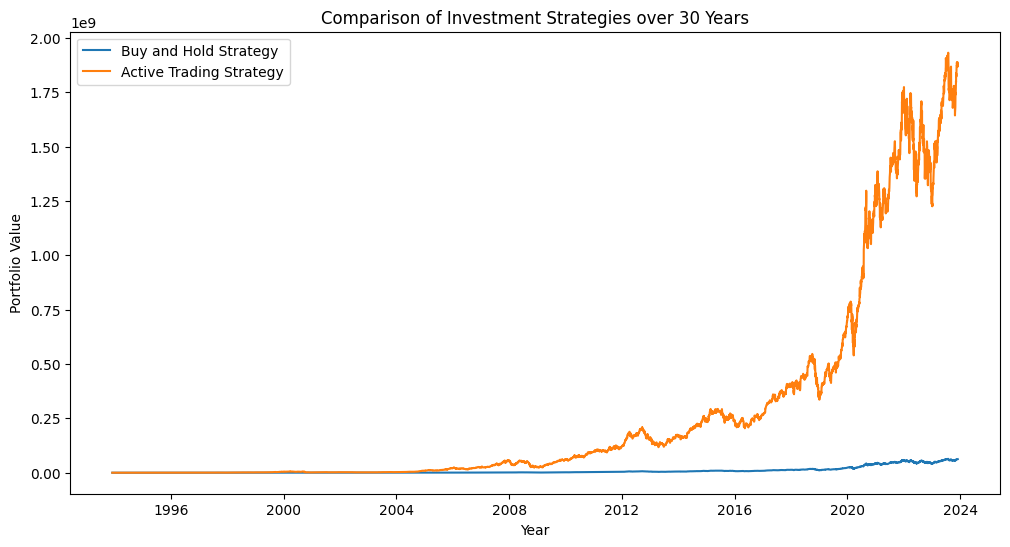

In [ ]:
#Compare Portfolio Strategies
plt.figure(figsize=(12, 6))
plt.plot(data['BuyHoldValue'], label='Buy and Hold Strategy')
plt.plot(data['ActiveTotalValue'], label='Active Trading Strategy')
plt.title('Comparison of Investment Strategies over 30 Years')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

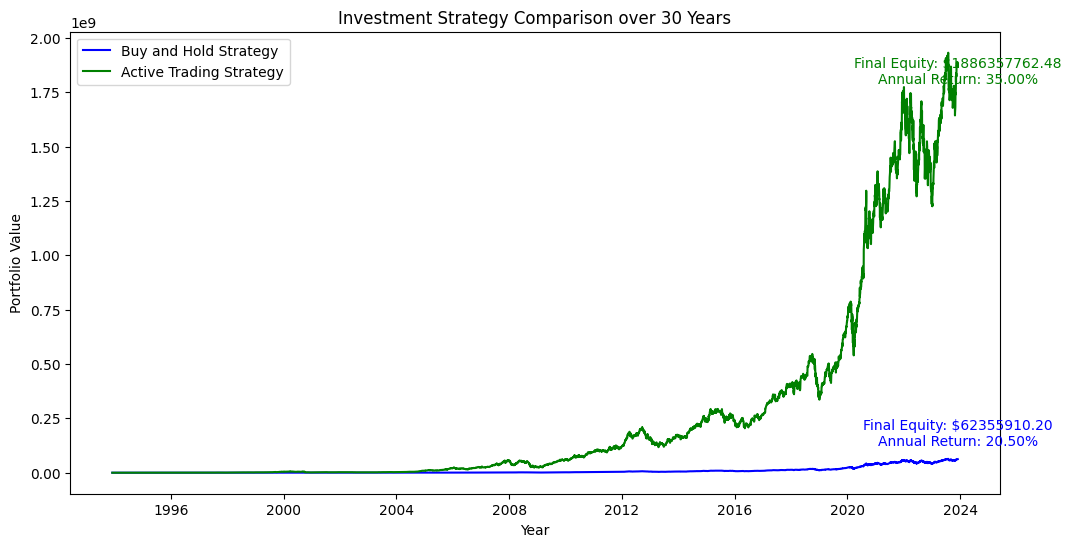

In [ ]:
# Visualization of Investment Strategies
plt.figure(figsize=(12, 6))
plt.plot(data['BuyHoldValue'], label='Buy and Hold Strategy', color='blue')
plt.plot(data['ActiveTotalValue'], label='Active Trading Strategy', color='green')

# Annotating the final equity and annual percent return for both strategies
buy_hold_final_value = data['BuyHoldValue'].iloc[-1]
buy_hold_annual_return = ((buy_hold_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / 30)) - 1

active_trading_final_value = data['ActiveTotalValue'].iloc[-1]
active_trading_annual_return = ((active_trading_final_value / data['BuyHoldCumInvestment'].iloc[-1]) ** (1 / 30)) - 1

plt.annotate(f'Final Equity: ${buy_hold_final_value:.2f}\nAnnual Return: {buy_hold_annual_return * 100:.2f}%',
             (data.index[-1], buy_hold_final_value),
             textcoords="offset points", xytext=(0,10), ha='center', color='blue')

plt.annotate(f'Final Equity: ${active_trading_final_value:.2f}\nAnnual Return: {active_trading_annual_return * 100:.2f}%',
             (data.index[-1], active_trading_final_value),
             textcoords="offset points", xytext=(0,-15), ha='center', color='green')

# Adding title and labels
plt.title(f'Investment Strategy Comparison over 30 Years')
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.legend()

# Show the plot
plt.show()